# Mapúa Makati Parking Entrance — Discrete-Event Simulation
**CSS142P Modelling and Simulation · Final Project · Group 8**
Ariola, Jon Luigi · Bauza, Xyrelle John · Caliliw, Marl Zeldrix · Jimenez, Justine Leee

**Question.** On a high-traffic morning, does one guard at the parking entrance risk a line backing onto Pablo Ocampo Sr. Extension, and would a second guard help?

**System (from group members' knowledge of the campus).**
- One booth and one guard serve a single wide lane used by both entering and exiting cars.
- Only cars with a parking sticker may enter; the guard checks the sticker.
- Cars without a sticker are refused but occupy the guard and lane while being turned away.
- Exiting cars drive out without a check, so they do not use the guard.
- Parking is in a two-level basement.

**Configurations.** A: one guard 07:00–19:00 (baseline) · B: second guard 07:00–09:00 · C: second guard 07:00–10:00

**Scenarios.** Demand ×0.8, ×1.0, ×1.2 (professor's request) · processing time ×0.8 and ×1.2 · a stress test from ×1 to ×5 demand. 30 replications each.

> **All numeric inputs are estimates**, because access to the entrance and its records was not available. The sensitivity scenarios and the stress test check whether the conclusion depends on them.

**How to run.** *Runtime → Run all* in Colab (or run top to bottom in Jupyter). Takes under a minute. Outputs are written to `results/` and `figures/`.

## 0. Setup
Installs SimPy (NumPy, pandas, SciPy and Matplotlib are already in Colab).

In [1]:
%pip install -q simpy

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import simpy
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
print("SimPy", simpy.__version__, "| NumPy", np.__version__, "| pandas", pd.__version__)

SimPy 4.1.2 | NumPy 2.4.4 | pandas 3.0.2


## 1. Input files
The model reads its inputs from `data/arrival_rates.csv` and `data/input_parameters.csv`. If you opened this notebook on its own in Colab (without the rest of the repository), the next cell creates those files with the group's estimates. If the files already exist, it leaves them untouched, **so to change an input, edit the CSV files and rerun.**

In [3]:
HERE = os.getcwd()
DATA, RESULTS, FIGURES = (os.path.join(HERE, d) for d in ("data", "results", "figures"))
for d in (DATA, RESULTS, FIGURES):
    os.makedirs(d, exist_ok=True)

if not os.path.exists(os.path.join(DATA, "arrival_rates.csv")):
    rates = [70, 90, 100, 95, 80, 70, 75, 80, 60, 50, 45, 40, 30, 30, 30, 30,
             25, 25, 25, 25, 25, 25, 25, 25, 30, 30, 30, 30, 20, 20, 20, 20,
             20, 20, 20, 20, 15, 15, 15, 15, 15, 15, 15, 15, 8, 8, 8, 8]
    pd.DataFrame({"interval_start": [f"{7 + i // 4:02d}:{(i % 4) * 15:02d}" for i in range(48)],
                  "arrivals_per_hour": rates}).to_csv(os.path.join(DATA, "arrival_rates.csv"), index=False)
    print("Created data/arrival_rates.csv with the group's estimates")

if not os.path.exists(os.path.join(DATA, "input_parameters.csv")):
    pd.DataFrame([
        ("sticker_mean_sec", 8, "seconds", "ESTIMATED. Car with a sticker: slows or stops, guard checks sticker, car proceeds."),
        ("sticker_sd_sec", 4, "seconds", "ESTIMATED. Lognormal distribution (positive, right-skewed)."),
        ("nonsticker_share", 0.05, "fraction of arrivals", "ESTIMATED. Refused entry but occupy the guard and lane while turned away."),
        ("nonsticker_mean_sec", 45, "seconds", "ESTIMATED. Time to refuse and clear the lane. Lognormal."),
        ("nonsticker_sd_sec", 15, "seconds", "ESTIMATED."),
        ("K_waiting_spaces", 8, "vehicles", "ESTIMATED. Waiting cars that fit before the line reaches Pablo Ocampo Sr. Ext."),
        ("guard2_close_B_min", 120, "minutes after 07:00", "Configuration B: second guard 07:00-09:00."),
        ("guard2_close_C_min", 180, "minutes after 07:00", "Configuration C: second guard 07:00-10:00."),
        ("replications", 30, "runs per scenario", "Proposal, Part 6."),
        ("base_seed", 20260914, "integer", "Recorded seed; every replication's random streams derive from this."),
    ], columns=["parameter", "value", "unit", "basis"]).to_csv(os.path.join(DATA, "input_parameters.csv"), index=False)
    print("Created data/input_parameters.csv with the group's estimates")

display(pd.read_csv(os.path.join(DATA, "input_parameters.csv")))

Created data/arrival_rates.csv with the group's estimates
Created data/input_parameters.csv with the group's estimates


,parameter,value,unit,basis
0,sticker_mean_sec,8.00,seconds,"ESTIMATED. Car with a sticker: slows or stops,..."
1,sticker_sd_sec,4.00,seconds,"ESTIMATED. Lognormal distribution (positive, r..."
2,nonsticker_share,0.05,fraction of arrivals,ESTIMATED. Refused entry but occupy the guard ...
3,nonsticker_mean_sec,45.00,seconds,ESTIMATED. Time to refuse and clear the lane. ...
4,nonsticker_sd_sec,15.00,seconds,ESTIMATED.
5,K_waiting_spaces,8.00,vehicles,ESTIMATED. Waiting cars that fit before the li...
6,guard2_close_B_min,120.00,minutes after 07:00,Configuration B: second guard 07:00-09:00.
7,guard2_close_C_min,180.00,minutes after 07:00,Configuration C: second guard 07:00-10:00.
8,replications,30.00,runs per scenario,"Proposal, Part 6."
9,base_seed,20260914.00,integer,Recorded seed; every replication's random stre...


## 2. Load inputs
Simulation clock: **minutes after 07:00** (0 = 07:00, 720 = 19:00). Processing times are lognormal; the combined mean and second moment are used later for verification.

Arrivals 07:00-10:00: 214 cars expected; whole day: 402
Mean processing time: 9.85 s  ->  one guard can check about 365 cars/hour


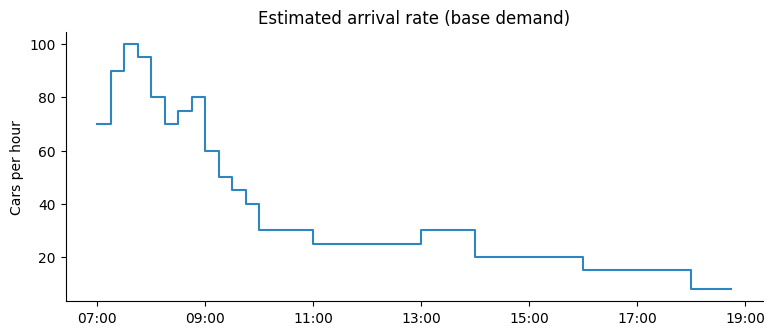

In [4]:
RATE_PER_MIN = pd.read_csv(os.path.join(DATA, "arrival_rates.csv"))["arrivals_per_hour"].to_numpy(float) / 60.0
INTERVAL = 15.0
DAY_END = INTERVAL * len(RATE_PER_MIN)        # 720 = 19:00
PEAK_END = 180.0                               # 10:00

p = pd.read_csv(os.path.join(DATA, "input_parameters.csv")).set_index("parameter")["value"].astype(float)
SHARE_NS = p["nonsticker_share"]
M1, S1 = p["sticker_mean_sec"] / 60, p["sticker_sd_sec"] / 60        # minutes
M2, S2 = p["nonsticker_mean_sec"] / 60, p["nonsticker_sd_sec"] / 60
K = int(p["K_waiting_spaces"])
REPS = int(p["replications"])
BASE_SEED = int(p["base_seed"])

CONFIGS = {  # name -> (closing time of guard 2 or None, guard-hours on duty)
    "A: 1 guard":           (None,                      12),
    "B: 2 guards 7-9 AM":   (p["guard2_close_B_min"],   14),
    "C: 2 guards 7-10 AM":  (p["guard2_close_C_min"],   15),
}


def lognormal_params(mean, sd):
    s2 = np.log(1 + (sd / mean) ** 2)
    return np.log(mean) - s2 / 2, np.sqrt(s2)


LN1, LN2 = lognormal_params(M1, S1), lognormal_params(M2, S2)
SVC_MEAN = (1 - SHARE_NS) * M1 + SHARE_NS * M2
SVC_EX2 = (1 - SHARE_NS) * (S1 ** 2 + M1 ** 2) + SHARE_NS * (S2 ** 2 + M2 ** 2)

print(f"Arrivals 07:00-10:00: {RATE_PER_MIN[:12].sum() * INTERVAL:.0f} cars expected; whole day: {RATE_PER_MIN.sum() * INTERVAL:.0f}")
print(f"Mean processing time: {SVC_MEAN * 60:.2f} s  ->  one guard can check about {60 / SVC_MEAN:.0f} cars/hour")
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.step(np.arange(48) * INTERVAL, RATE_PER_MIN * 60, where="post", color="#2E86C1")
ax.set_xticks(np.arange(0, 721, 120), ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"])
ax.set_ylabel("Cars per hour"); ax.set_title("Estimated arrival rate (base demand)")
ax.spines[["top", "right"]].set_visible(False); plt.show()

## 3. Random inputs with common random numbers
Arrivals are a non-homogeneous Poisson process with a rate that is constant within each 15-minute interval, generated by inverting the cumulative rate function.

**Common random numbers.** Each replication has separate random streams: stream 0 for arrivals, stream 1 for sticker or no sticker, streams 2 and 3 for check times. Car *i* is therefore the same car (same arrival, same type, same check time) in every configuration and every demand level, so differences between configurations reflect staffing, not luck.

In [5]:
def rng(rep, stream):
    return np.random.default_rng([BASE_SEED, rep, stream])


def arrival_times(rep, demand_factor):
    """Non-homogeneous Poisson arrivals, piecewise-constant rate, generated by
    inverting the cumulative rate function. The same unit-rate exponentials
    drive every configuration and every demand level in a replication."""
    rate = RATE_PER_MIN * demand_factor
    cum = np.concatenate([[0.0], np.cumsum(rate * INTERVAL)])
    r = rng(rep, 0)
    s = np.cumsum(r.exponential(1.0, int(cum[-1] * 1.6) + 200))
    while s[-1] < cum[-1]:
        s = np.concatenate([s, s[-1] + np.cumsum(r.exponential(1.0, 500))])
    s = s[s < cum[-1]]
    idx = np.searchsorted(cum, s, side="right") - 1
    return idx * INTERVAL + (s - cum[idx]) / rate[idx]


def vehicle_attributes(rep, n, service_factor):
    """Vehicle i's type and processing time come from fixed positions in
    separate streams, so vehicle i is identical in every scenario."""
    no_sticker = rng(rep, 1).random(n) < SHARE_NS
    t1 = rng(rep, 2).lognormal(*LN1, n)
    t2 = rng(rep, 3).lognormal(*LN2, n)
    return np.where(no_sticker, t2, t1) * service_factor, no_sticker

## 4. The discrete-event model
- **State:** number of cars waiting in the shared line; each guard busy or idle.
- **Events:** car arrival · sticker check starts · check ends · second guard goes off duty (09:00 in B, 10:00 in C).
- One first-come, first-served line feeds whichever guard is free. Guard 2 takes no new car after going off duty but finishes the current one.
- Arrivals stop at 19:00; cars still in line are processed. Each day starts empty.
- **Measures:** average wait (all cars, and cars arriving 07:00–10:00), longest wait, longest line, spillover minutes (time with at least K cars waiting), guard utilization (busy time ÷ on-duty time).

In [6]:
def simulate(arr, svc, close2, k=K, day_end=DAY_END):
    """One operating day. One shared FIFO line feeds the guards on duty.
    Guard 2 takes no new car after close2 but finishes the current one.
    Arrivals stop at day_end; cars still in line are then processed."""
    env = simpy.Environment()
    line = simpy.Store(env)
    n = len(arr)
    start = np.full(n, np.nan)
    busy, last = {1: 0.0, 2: 0.0}, {1: 0.0, 2: 0.0}
    q_t, q_n = [0.0], [0]

    def log_queue():
        q_t.append(env.now)
        q_n.append(len(line.items))

    def arrivals():
        for i, t in enumerate(arr):
            yield env.timeout(t - env.now)
            line.put(i)                                  # event: arrival
            log_queue()

    def serve(g, i):
        start[i] = env.now                               # event: check starts
        log_queue()
        yield env.timeout(svc[i])                        # event: check ends
        busy[g] += svc[i]
        last[g] = env.now

    def guard(g, close):
        while True:
            if close is None:
                i = yield line.get()
            else:
                remaining = close - env.now
                if remaining <= 0:
                    return                               # event: guard 2 goes off duty
                req = line.get()
                done = yield req | env.timeout(remaining)
                if req in done or req.triggered:
                    i = req.value
                else:
                    req.cancel()
                    return
            yield from serve(g, i)

    env.process(arrivals())
    env.process(guard(1, None))
    if close2 is not None:
        env.process(guard(2, close2))
    env.run()

    wait = start - arr
    q_t, q_n = np.array(q_t), np.array(q_n)
    staffed = max(day_end, last[1]) + (max(close2, last[2]) if close2 is not None else 0)
    return {
        "vehicles": n,
        "avg_wait_sec": wait.mean() * 60,
        "avg_wait_peak_sec": wait[arr < PEAK_END].mean() * 60,
        "max_wait_sec": wait.max() * 60,
        "max_queue": int(q_n.max()),
        "spillover_min": np.diff(q_t)[q_n[:-1] >= k].sum(),
        "utilization": (busy[1] + busy[2]) / staffed,
        "_q_t": q_t, "_q_n": q_n,
    }


def queue_at(q_t, q_n, times):
    return q_n[np.searchsorted(q_t, times, side="right") - 1]


def ci(x):
    x = np.asarray(x, float)
    return x.mean(), stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))

## 5. Verification
Two checks that the code is correct, independent of the estimated inputs:
1. **Exactness.** With one guard, the model's waiting times must equal the Lindley recursion $W_i = \max(0,\ W_{i-1} + S_{i-1} - (A_i - A_{i-1}))$ on the same inputs.
2. **Theory.** At a constant arrival rate giving 75% utilization over long runs, the mean wait should match the Pollaczek–Khinchine M/G/1 formula $W_q = \dfrac{\lambda E[S^2]}{2(1-\rho)}$.

In [7]:
def verify_mg1(reps=10, rho=0.75, horizon=20000.0):
    """(1) With one guard, the model's waits must equal the Lindley recursion
    on the same inputs. (2) At a constant arrival rate over a long run, the
    mean wait should match the Pollaczek-Khinchine M/G/1 formula."""
    lam = rho / SVC_MEAN
    theory = lam * SVC_EX2 / (2 * (1 - rho))
    means, gap = [], 0.0
    for r in range(reps):
        g = np.random.default_rng([BASE_SEED, 999, r])
        arr = np.cumsum(g.exponential(1 / lam, int(lam * horizon * 1.2)))
        arr = arr[arr < horizon]
        ns = g.random(len(arr)) < SHARE_NS
        svc = np.where(ns, g.lognormal(*LN2, len(arr)), g.lognormal(*LN1, len(arr)))
        out = simulate(arr, svc, None, day_end=horizon)
        w = np.zeros(len(arr))
        for i in range(1, len(arr)):
            w[i] = max(0.0, w[i - 1] + svc[i - 1] - (arr[i] - arr[i - 1]))
        means.append(out["avg_wait_sec"])
        gap = max(gap, abs(out["avg_wait_sec"] - w.mean() * 60))
    mu, h = ci(means)
    return pd.DataFrame({
        "check": [f"One guard, constant {lam*60:.0f} cars/hr, 20,000-minute runs"],
        "utilization_rho": [rho],
        "PK_formula_mean_wait_sec": [theory * 60],
        "simulated_mean_wait_sec": [mu],
        "simulated_ci95_halfwidth_sec": [h],
        "max_abs_gap_vs_lindley_sec": [gap],
        "replications": [reps],
    })

ver = verify_mg1()
ver.round(3).to_csv(os.path.join(RESULTS, "verification_mg1.csv"), index=False)
display(ver.round(3))

,check,utilization_rho,PK_formula_mean_wait_sec,simulated_mean_wait_sec,simulated_ci95_halfwidth_sec,max_abs_gap_vs_lindley_sec,replications
0,"One guard, constant 274 cars/hr, 20,000-minute...",0.75,28.706,28.396,0.804,0.0,10


## 6. Experiments
Runs 5 scenarios × 3 configurations × 30 replications (450 simulated days), plus the stress test for A and B.

In [8]:
SCENARIOS = [
    (0.8, 1.0, "Demand -20%"),
    (1.0, 1.0, "Base demand"),
    (1.2, 1.0, "Demand +20%"),
    (1.0, 0.8, "Processing time -20%"),
    (1.0, 1.2, "Processing time +20%"),
]
METRICS = ["avg_wait_sec", "avg_wait_peak_sec", "max_wait_sec", "max_queue", "spillover_min", "utilization"]
STRESS = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
MINUTES = np.arange(0, 241)


def summarize(reps, keys):
    out = []
    for key, g in reps.groupby(keys, sort=False):
        r = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        r["guard_hours"] = g["guard_hours"].iloc[0]
        r["vehicles_mean"] = g["vehicles"].mean()
        for m in METRICS:
            r[m + "_mean"], r[m + "_ci95"] = ci(g[m])
        out.append(r)
    return pd.DataFrame(out)


def run():
    rows, profiles, stress = [], [], []
    for rep in range(REPS):
        for d, s, label in SCENARIOS:
            arr = arrival_times(rep, d)
            svc, _ = vehicle_attributes(rep, len(arr), s)
            for cfg, (close2, hours) in CONFIGS.items():
                out = simulate(arr, svc, close2)
                rows.append({"scenario": label, "demand_factor": d, "processing_factor": s,
                             "config": cfg, "replication": rep + 1, "guard_hours": hours,
                             **{m: out[m] for m in ["vehicles"] + METRICS}})
                if label == "Base demand":
                    profiles.append(pd.DataFrame({"config": cfg, "minute": MINUTES,
                                                  "queue": queue_at(out["_q_t"], out["_q_n"], MINUTES)}))
        for d in STRESS:
            arr = arrival_times(rep, d)
            svc, _ = vehicle_attributes(rep, len(arr), 1.0)
            for cfg in ["A: 1 guard", "B: 2 guards 7-9 AM"]:
                out = simulate(arr, svc, CONFIGS[cfg][0])
                stress.append({"demand_factor": d, "config": cfg, "replication": rep + 1,
                               "guard_hours": CONFIGS[cfg][1],
                               **{m: out[m] for m in ["vehicles"] + METRICS}})

    reps = pd.DataFrame(rows)
    reps.to_csv(os.path.join(RESULTS, "replications.csv"), index=False)
    summ = summarize(reps, ["scenario", "config"])
    summ.round(3).to_csv(os.path.join(RESULTS, "summary_by_scenario.csv"), index=False)

    cfgs = list(CONFIGS)
    diffs = []
    for label, g in reps.groupby("scenario", sort=False):
        w = g.pivot(index="replication", columns="config")
        for x, y in [(cfgs[1], cfgs[0]), (cfgs[2], cfgs[0]), (cfgs[2], cfgs[1])]:
            for m in ["avg_wait_peak_sec", "max_queue", "spillover_min"]:
                mu, h = ci(w[m][x] - w[m][y])
                diffs.append({"scenario": label, "comparison": f"{x[0]} - {y[0]}", "metric": m,
                              "mean_difference": mu, "ci95_low": mu - h, "ci95_high": mu + h,
                              "significant_at_95": bool(h > 0 and not (mu - h <= 0 <= mu + h))})
    diffs = pd.DataFrame(diffs)
    diffs.round(3).to_csv(os.path.join(RESULTS, "paired_differences.csv"), index=False)

    stress = summarize(pd.DataFrame(stress), ["demand_factor", "config"])
    stress.round(3).to_csv(os.path.join(RESULTS, "stress_test.csv"), index=False)

    prof = pd.concat(profiles).groupby(["config", "minute"], sort=False)["queue"].mean().reset_index()
    prof.to_csv(os.path.join(RESULTS, "queue_profile_base_demand.csv"), index=False)

    return summ, diffs, stress, prof

summ, diffs, stress, prof = run()
print("Done. Results saved to results/")

Done. Results saved to results/


### 6.1 Summary by scenario
Means of 30 replications (`_ci95` columns are 95% confidence-interval half-widths in the full CSV).

In [9]:
cols = ["scenario", "config", "avg_wait_peak_sec_mean", "max_wait_sec_mean", "max_queue_mean", "spillover_min_mean", "utilization_mean"]
display(summ[cols].round(2))

,scenario,config,avg_wait_peak_sec_mean,max_wait_sec_mean,max_queue_mean,spillover_min_mean,utilization_mean
0,Demand -20%,A: 1 guard,1.88,54.08,2.83,0.0,0.07
1,Demand -20%,B: 2 guards 7-9 AM,0.27,32.25,1.57,0.0,0.06
2,Demand -20%,C: 2 guards 7-10 AM,0.06,26.23,1.40,0.0,0.06
3,Base demand,A: 1 guard,2.41,60.53,3.33,0.0,0.09
4,Base demand,B: 2 guards 7-9 AM,0.42,40.72,2.00,0.0,0.08
5,Base demand,C: 2 guards 7-10 AM,0.10,31.81,1.63,0.0,0.07
6,Demand +20%,A: 1 guard,2.88,64.46,3.77,0.0,0.11
7,Demand +20%,B: 2 guards 7-9 AM,0.41,43.04,2.17,0.0,0.09
8,Demand +20%,C: 2 guards 7-10 AM,0.13,38.06,2.07,0.0,0.09
9,Processing time -20%,A: 1 guard,1.49,45.86,3.00,0.0,0.07


### 6.2 Paired differences between configurations
Negative = the first configuration is better. Valid as paired comparisons because of common random numbers.

In [10]:
display(diffs[diffs["metric"] != "spillover_min"].round(3))

,scenario,comparison,metric,mean_difference,ci95_low,ci95_high,significant_at_95
0,Demand -20%,B - A,avg_wait_peak_sec,-1.612,-1.932,-1.291,True
1,Demand -20%,B - A,max_queue,-1.267,-1.704,-0.829,True
3,Demand -20%,C - A,avg_wait_peak_sec,-1.827,-2.157,-1.496,True
4,Demand -20%,C - A,max_queue,-1.433,-1.846,-1.021,True
6,Demand -20%,C - B,avg_wait_peak_sec,-0.215,-0.301,-0.129,True
7,Demand -20%,C - B,max_queue,-0.167,-0.308,-0.025,True
9,Base demand,B - A,avg_wait_peak_sec,-1.986,-2.304,-1.668,True
10,Base demand,B - A,max_queue,-1.333,-1.797,-0.870,True
12,Base demand,C - A,avg_wait_peak_sec,-2.312,-2.656,-1.968,True
13,Base demand,C - A,max_queue,-1.700,-2.118,-1.282,True


### 6.3 Stress test
How much must demand grow before one guard lets the line reach the street?

In [11]:
display(stress[["demand_factor", "config", "avg_wait_peak_sec_mean", "max_queue_mean", "spillover_min_mean"]].round(2))

,demand_factor,config,avg_wait_peak_sec_mean,max_queue_mean,spillover_min_mean
0,1.0,A: 1 guard,2.41,3.33,0.00
1,1.0,B: 2 guards 7-9 AM,0.42,2.00,0.00
2,1.5,A: 1 guard,4.04,4.40,0.00
3,1.5,B: 2 guards 7-9 AM,0.73,2.83,0.00
4,2.0,A: 1 guard,6.78,6.23,0.23
5,2.0,B: 2 guards 7-9 AM,1.11,3.57,0.00
6,2.5,A: 1 guard,10.80,8.20,1.38
7,2.5,B: 2 guards 7-9 AM,1.49,4.20,0.00
8,3.0,A: 1 guard,20.41,13.03,6.76
9,3.0,B: 2 guards 7-9 AM,2.26,5.80,0.01


## 7. Charts
Saved to `figures/` as well as shown here.

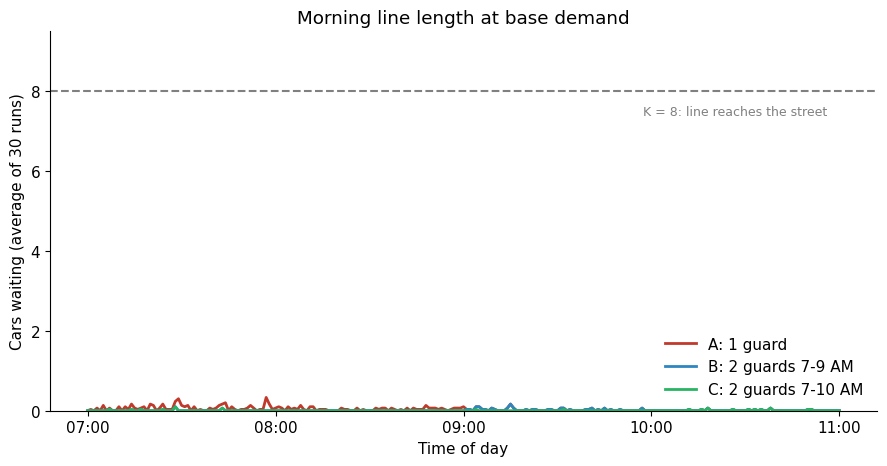

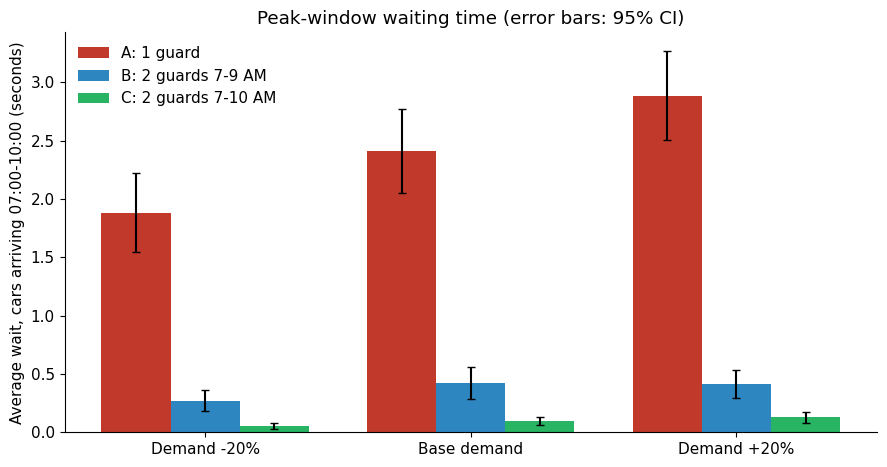

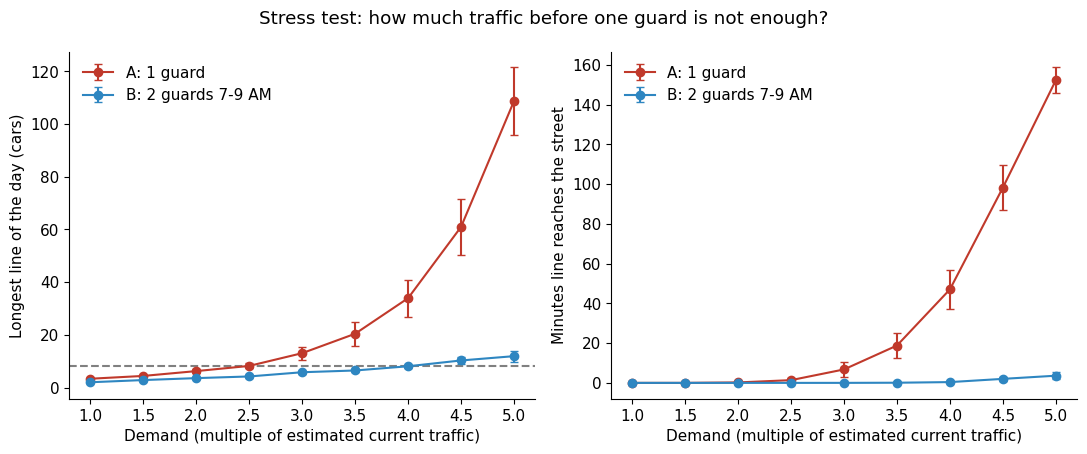

In [12]:
COLORS = {"A: 1 guard": "#C0392B", "B: 2 guards 7-9 AM": "#2E86C1", "C: 2 guards 7-10 AM": "#28B463"}


def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)


def charts(summ, stress, prof):
    plt.rcParams.update({"font.size": 11})

    fig, ax = plt.subplots(figsize=(9, 4.8))
    for cfg, g in prof.groupby("config", sort=False):
        ax.plot(g["minute"], g["queue"], label=cfg, color=COLORS[cfg], lw=2)
    ax.axhline(K, ls="--", color="grey")
    ax.text(236, K - 0.6, f"K = {K}: line reaches the street", ha="right", color="grey", fontsize=9)
    ax.set_xticks([0, 60, 120, 180, 240], ["07:00", "08:00", "09:00", "10:00", "11:00"])
    ax.set_ylim(0, K + 1.5)
    ax.set_xlabel("Time of day")
    ax.set_ylabel("Cars waiting (average of 30 runs)")
    ax.set_title("Morning line length at base demand")
    style(ax)
    fig.tight_layout(); fig.savefig(os.path.join(FIGURES, "queue_profile_base_demand.png"), dpi=200); plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.8))
    scen = ["Demand -20%", "Base demand", "Demand +20%"]
    x, w = np.arange(3), 0.26
    for j, cfg in enumerate(CONFIGS):
        sub = summ[summ["config"] == cfg].set_index("scenario").loc[scen]
        ax.bar(x + (j - 1) * w, sub["avg_wait_peak_sec_mean"], w, yerr=sub["avg_wait_peak_sec_ci95"],
               capsize=3, label=cfg, color=COLORS[cfg])
    ax.set_xticks(x, scen)
    ax.set_ylabel("Average wait, cars arriving 07:00-10:00 (seconds)")
    ax.set_title("Peak-window waiting time (error bars: 95% CI)")
    style(ax)
    fig.tight_layout(); fig.savefig(os.path.join(FIGURES, "peak_wait_by_demand.png"), dpi=200); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for cfg, g in stress.groupby("config", sort=False):
        axes[0].errorbar(g["demand_factor"], g["max_queue_mean"], yerr=g["max_queue_ci95"],
                         marker="o", capsize=3, label=cfg, color=COLORS[cfg])
        axes[1].errorbar(g["demand_factor"], g["spillover_min_mean"], yerr=g["spillover_min_ci95"],
                         marker="o", capsize=3, label=cfg, color=COLORS[cfg])
    axes[0].axhline(K, ls="--", color="grey")
    axes[0].set_ylabel("Longest line of the day (cars)")
    axes[1].set_ylabel("Minutes line reaches the street")
    for ax in axes:
        ax.set_xlabel("Demand (multiple of estimated current traffic)")
        style(ax)
    fig.suptitle("Stress test: how much traffic before one guard is not enough?")
    fig.tight_layout(); fig.savefig(os.path.join(FIGURES, "stress_test.png"), dpi=200); plt.show()

charts(summ, stress, prof)

## 8. Key findings
Computed from the results above, so they update automatically if the inputs change.

In [13]:
b = summ[summ["scenario"] == "Base demand"].set_index("config")
A, B, C = list(CONFIGS)
print(f"Base demand, one guard: average peak wait {b.loc[A, 'avg_wait_peak_sec_mean']:.1f} s, "
      f"longest line {b.loc[A, 'max_queue_mean']:.1f} cars, spillover {b.loc[A, 'spillover_min_mean']:.1f} min")
print(f"Second guard 7-9 AM: peak wait {b.loc[B, 'avg_wait_peak_sec_mean']:.1f} s; 7-10 AM: {b.loc[C, 'avg_wait_peak_sec_mean']:.1f} s")
sens = summ[summ["config"] == A]
print(f"Across all five scenarios, one guard's spillover ranges {sens['spillover_min_mean'].min():.1f}-{sens['spillover_min_mean'].max():.1f} min")
sA = stress[stress["config"] == A]
first = sA[sA["spillover_min_mean"] >= 1.0]["demand_factor"]
print("One guard first averages 1+ minute of spillover at demand x" + (f"{first.iloc[0]:.1f}" if len(first) else " >5.0 (not reached)"))

Base demand, one guard: average peak wait 2.4 s, longest line 3.3 cars, spillover 0.0 min
Second guard 7-9 AM: peak wait 0.4 s; 7-10 AM: 0.1 s
Across all five scenarios, one guard's spillover ranges 0.0-0.0 min
One guard first averages 1+ minute of spillover at demand x2.5


**Interpretation (with the estimated inputs).** A sticker check is fast, so one guard's capacity is several times the estimated peak arrival rate. At current traffic, and under every ±20% change to demand or processing time, the line stays short and never reaches the street. A second guard shortens waits by only a second or two, which does not justify the extra guard-hours. One guard begins to fail only if morning traffic grows to roughly two and a half times the current estimate; a second guard from 07:00 to 09:00 would then hold up to about four times.

**Limitations.** Every numeric input is estimated. The share of cars without stickers and their handling time are assumptions, as is K. Finding a space inside the basement is outside the model, and could be a separate bottleneck the entrance model cannot see.